In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity


In [16]:
# Loads data file
# @param filePath - Path to parquet file
# @returns - Loaded dataset dataframe
def loadProcessedData(filePath):
    return pd.read_parquet(filePath)

# Cleans and standardizes venue names
# @param nameString - Raw venue name
# @returns - Cleaned venue name
def cleanVenueName(nameString):
    if not isinstance(nameString, str):
        return "UNKNOWN"
    upperName = nameString.upper().strip()
    if "ARXIV" in upperName or upperName == "CORR":
        return "ARXIV"
    if upperName == "NONE" or upperName == "":
        return "UNKNOWN"
    if len(upperName) > 40:
        return upperName[:37] + "..."
    return upperName

analyticalData = loadProcessedData("../../data/processed_dblp.parquet")

analyticalData = analyticalData[(analyticalData["year"] >= 1950) & (analyticalData["year"] <= 2026)].copy()
analyticalData["venue"] = analyticalData["venue"].apply(cleanVenueName)
analyticalData["authorCount"] = analyticalData["authors"].apply(len)
analyticalData["referenceCount"] = analyticalData["references"].apply(lambda refList: len(refList) if refList is not None else 0)

baseColumns =["id", "venue", "year", "n_citation", "authors", "references", "authorCount", "referenceCount"]
textColumns = [col for col in analyticalData.columns if col not in baseColumns]


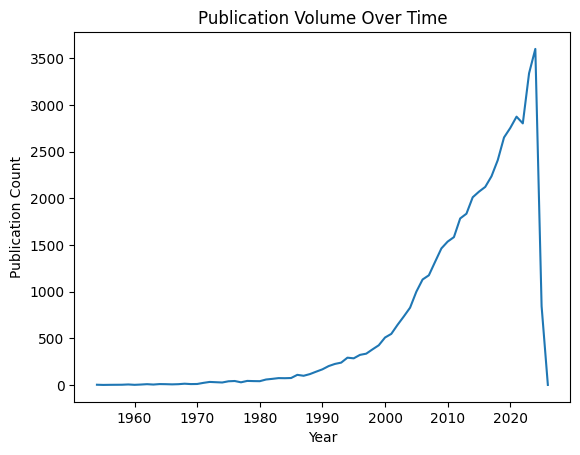

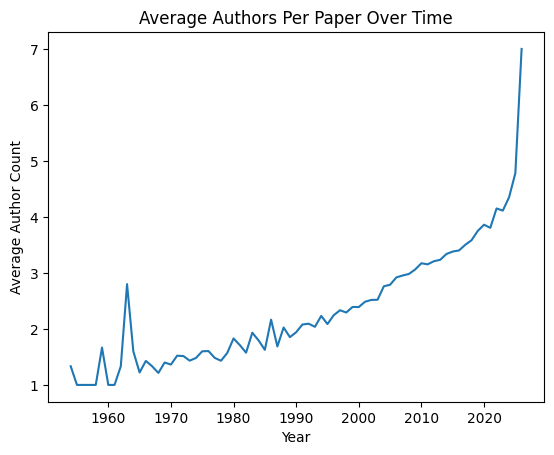

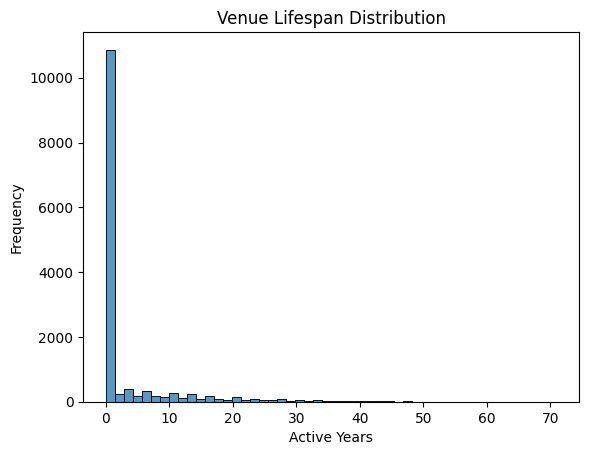

In [ ]:
plt.figure()
publicationsPerYear = analyticalData["year"].value_counts().sort_index()
sns.lineplot(x=publicationsPerYear.index, y=publicationsPerYear.values)
plt.title("Publication Volume Over Time")
plt.xlabel("Year")
plt.ylabel("Publication Count")
plt.show()

plt.figure()
avgAuthorsPerYear = analyticalData.groupby("year")["authorCount"].mean()
sns.lineplot(x=avgAuthorsPerYear.index, y=avgAuthorsPerYear.values)
plt.title("Average Authors Per Paper Over Time")
plt.xlabel("Year")
plt.ylabel("Average Author Count")
plt.show()

plt.figure()
venueLifespan = analyticalData.groupby("venue")["year"].max() - analyticalData.groupby("venue")["year"].min()
sns.histplot(venueLifespan, bins=25, kde=False)
plt.title("Venue Lifespan Distribution")
plt.xlabel("Active Years")
plt.ylabel("Frequency")
plt.show()


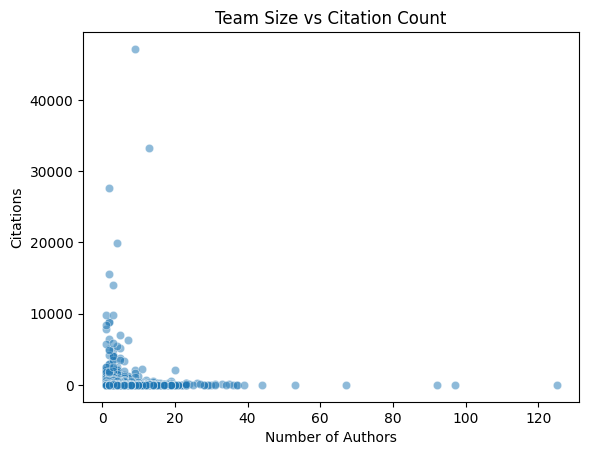

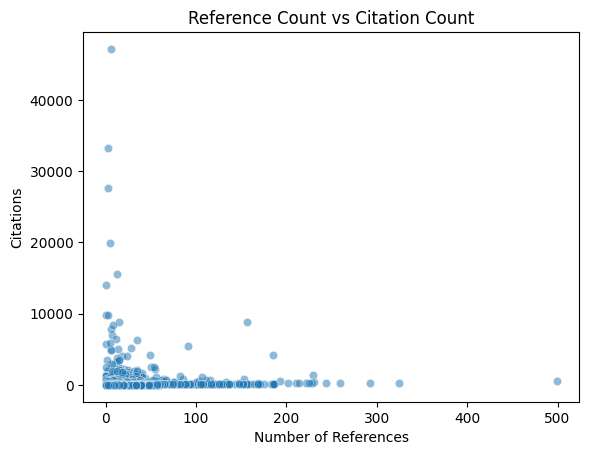

Citation Gini coefficient: 0.714562100154919


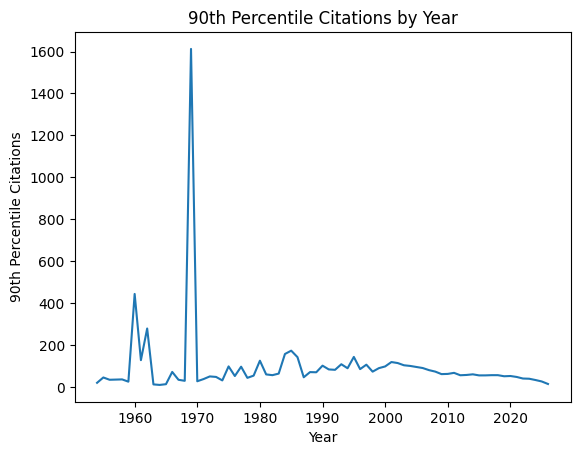

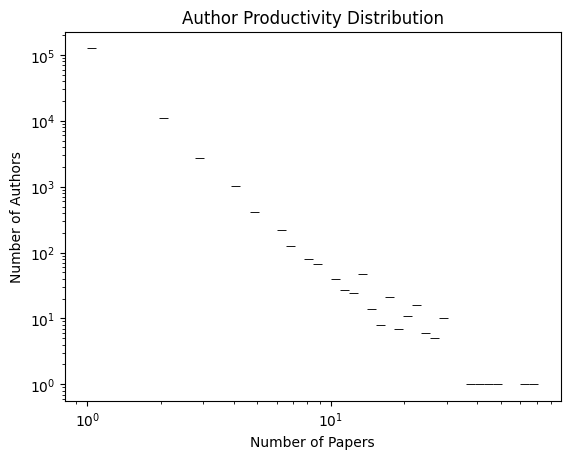

In [ ]:
plt.figure()
sns.scatterplot(x="authorCount", y="n_citation", data=analyticalData, alpha=0.5)
plt.title("Team Size vs Citation Count")
plt.xlabel("Number of Authors")
plt.ylabel("Citations")
plt.show()

plt.figure()
sns.scatterplot(x="referenceCount", y="n_citation", data=analyticalData, alpha=0.5)
plt.title("Reference Count vs Citation Count")
plt.xlabel("Number of References")
plt.ylabel("Citations")
plt.show()

# Calculates Gini coefficient for numerical array
# @param values - Array of numerical values
# @returns - Gini coefficient float
def calculateGiniCoefficient(values):
    sortedValues = np.sort(values)
    totalSum = np.sum(sortedValues)
    if totalSum == 0:
        return 0.0
    index = np.arange(1, len(values) + 1)
    return (np.sum((2 * index - len(values) - 1) * sortedValues)) / (len(values) * totalSum)

giniCoefficient = calculateGiniCoefficient(analyticalData["n_citation"].values)
print(f"Citation Gini coefficient: {giniCoefficient}")

plt.figure()
thresholdsByYear = analyticalData.groupby("year")["n_citation"].quantile(0.9)
sns.lineplot(x=thresholdsByYear.index, y=thresholdsByYear.values)
plt.title("90th Percentile Citations by Year")
plt.xlabel("Year")
plt.ylabel("90th Percentile Citations")
plt.show()


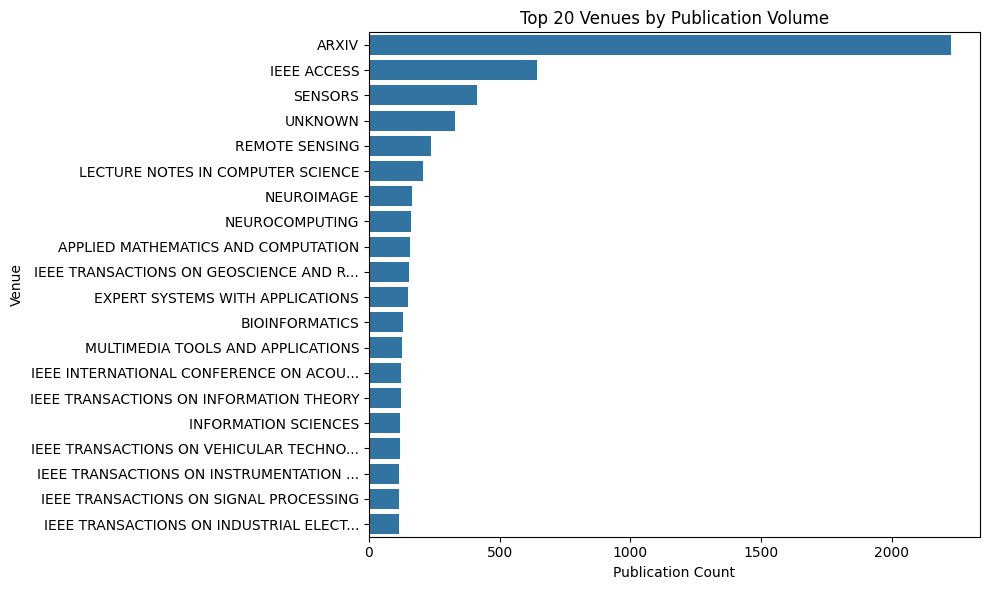

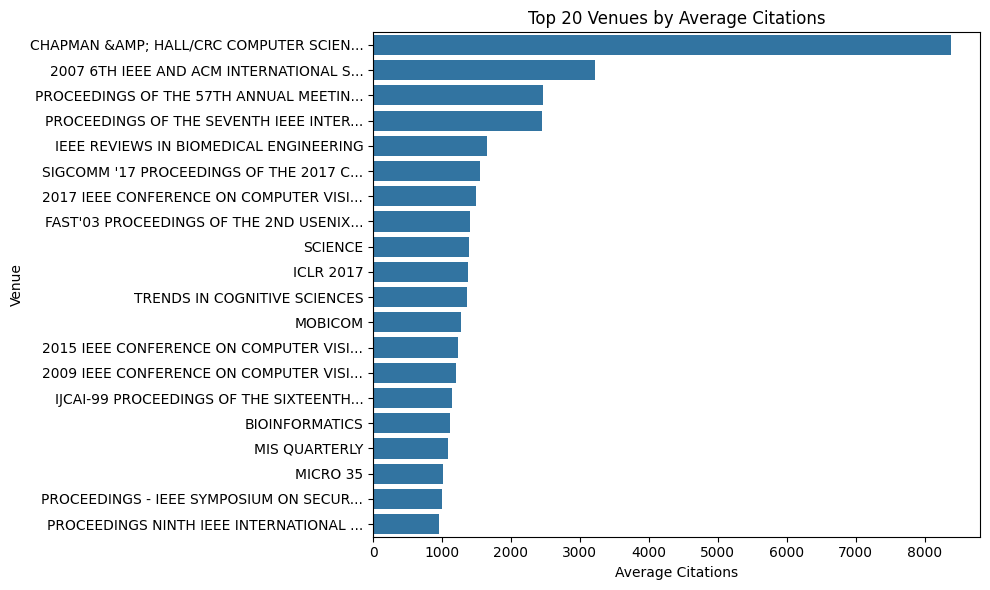

In [19]:
plt.figure(figsize=(10, 6))
venueVolume = analyticalData["venue"].value_counts().head(20)
sns.barplot(y=venueVolume.index, x=venueVolume.values)
plt.title("Top 20 Venues by Publication Volume")
plt.xlabel("Publication Count")
plt.ylabel("Venue")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
venueImpact = analyticalData.groupby("venue")["n_citation"].mean().sort_values(ascending=False).head(20)
sns.barplot(y=venueImpact.index, x=venueImpact.values)
plt.title("Top 20 Venues by Average Citations")
plt.xlabel("Average Citations")
plt.ylabel("Venue")
plt.tight_layout()
plt.show()


Terms per Venue:
ARXIV: ['models', 'data', 'model', 'learning', 'based']
IEEE ACCESS: ['proposed', 'based', 'model', 'method', 'data']
SENSORS: ['based', 'proposed', 'detection', 'data', 'using']
UNKNOWN: ['paper', 'data', 'based', 'model', 'proposed']
REMOTE SENSING: ['data', 'study', 'model', 'high', 'results']
LECTURE NOTES IN COMPUTER SCIENCE: ['paper', 'based', 'data', 'model', 'problem']
NEUROIMAGE: ['using', 'results', 'study', 'data', 'different']
NEUROCOMPUTING: ['network', 'proposed', 'model', 'learning', 'data']
APPLIED MATHEMATICS AND COMPUTATION: ['method', 'paper', 'order', 'problem', 'results']
IEEE TRANSACTIONS ON GEOSCIENCE AND R...: ['data', 'method', 'based', 'proposed', 'model']

Intra-Venue Semantic Similarity:
ARXIV: 0.1497
IEEE ACCESS: 0.2013
SENSORS: 0.1864
UNKNOWN: 0.0442
REMOTE SENSING: 0.2528
LECTURE NOTES IN COMPUTER SCIENCE: 0.1408
NEUROIMAGE: 0.1747
NEUROCOMPUTING: 0.2182
APPLIED MATHEMATICS AND COMPUTATION: 0.1520
IEEE TRANSACTIONS ON GEOSCIENCE AND R...:

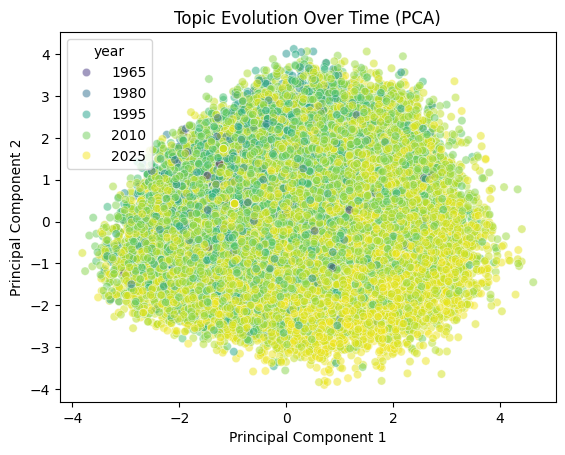

In [ ]:
# Extracts terms per venue
# @param dataFrame - Dataset containing venue and text features
# @param columns - List of feature names
# @param topK - Number of top venues to analyze
# @param termK - Number of top terms to extract
# @returns - Dictionary mapping venue to terms
def extractTopVenueTerms(dataFrame, columns, topK, termK):
    topVenues = dataFrame["venue"].value_counts().head(topK).index
    venueGroup = dataFrame[dataFrame["venue"].isin(topVenues)].groupby("venue")[columns].mean()
    topTermsDict = {}
    for venue in topVenues:
        topTermsDict[venue] = venueGroup.loc[venue].nlargest(termK).index.tolist()
    return topTermsDict

topVenueTerms = extractTopVenueTerms(analyticalData, textColumns, 10, 5)
print("Terms per venue:")
for venue, terms in topVenueTerms.items():
    print(f"{venue}: {terms}")

# Calculates intra-venue semantic similarity
# @param dataFrame - Dataset containing venue and text features
# @param columns - List of feature names
# @param topK - Number of top venues to analyze
# @returns - Dictionary mapping venue to similarity
def calculateIntraVenueSimilarity(dataFrame, columns, topK):
    topVenues = dataFrame["venue"].value_counts().head(topK).index
    similarityDict = {}
    for venue in topVenues:
        venueVectors = dataFrame[dataFrame["venue"] == venue][columns].values
        if len(venueVectors) > 1:
            similarityMatrix = cosine_similarity(venueVectors)
            upperTriangleIndices = np.triu_indices_from(similarityMatrix, k=1)
            similarityDict[venue] = np.mean(similarityMatrix[upperTriangleIndices])
        else:
            similarityDict[venue] = 0.0
    return similarityDict

intraVenueSimilarity = calculateIntraVenueSimilarity(analyticalData, textColumns, 10)
print("\nIntra-venue semantic similarity:")
for venue, similarity in intraVenueSimilarity.items():
    print(f"{venue}: {similarity:.4f}")

# Applies principal component analysis
# @param featureMatrix - Numerical features
# @param components - Number of target dimensions
# @returns - Transformed coordinates
def reduceDimensions(featureMatrix, components):
    scaler = StandardScaler()
    scaledFeatures = scaler.fit_transform(featureMatrix)
    pcaModel = PCA(n_components=components)
    return pcaModel.fit_transform(scaledFeatures)

coordinates = reduceDimensions(analyticalData[textColumns], 2)
plt.figure()
sns.scatterplot(x=coordinates[:, 0], y=coordinates[:, 1], hue=analyticalData["year"], palette="viridis", alpha=0.5)
plt.title("Topic Evolution Over Time (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()


Co-authorship network average clustering coefficient: 0.7701446569902498


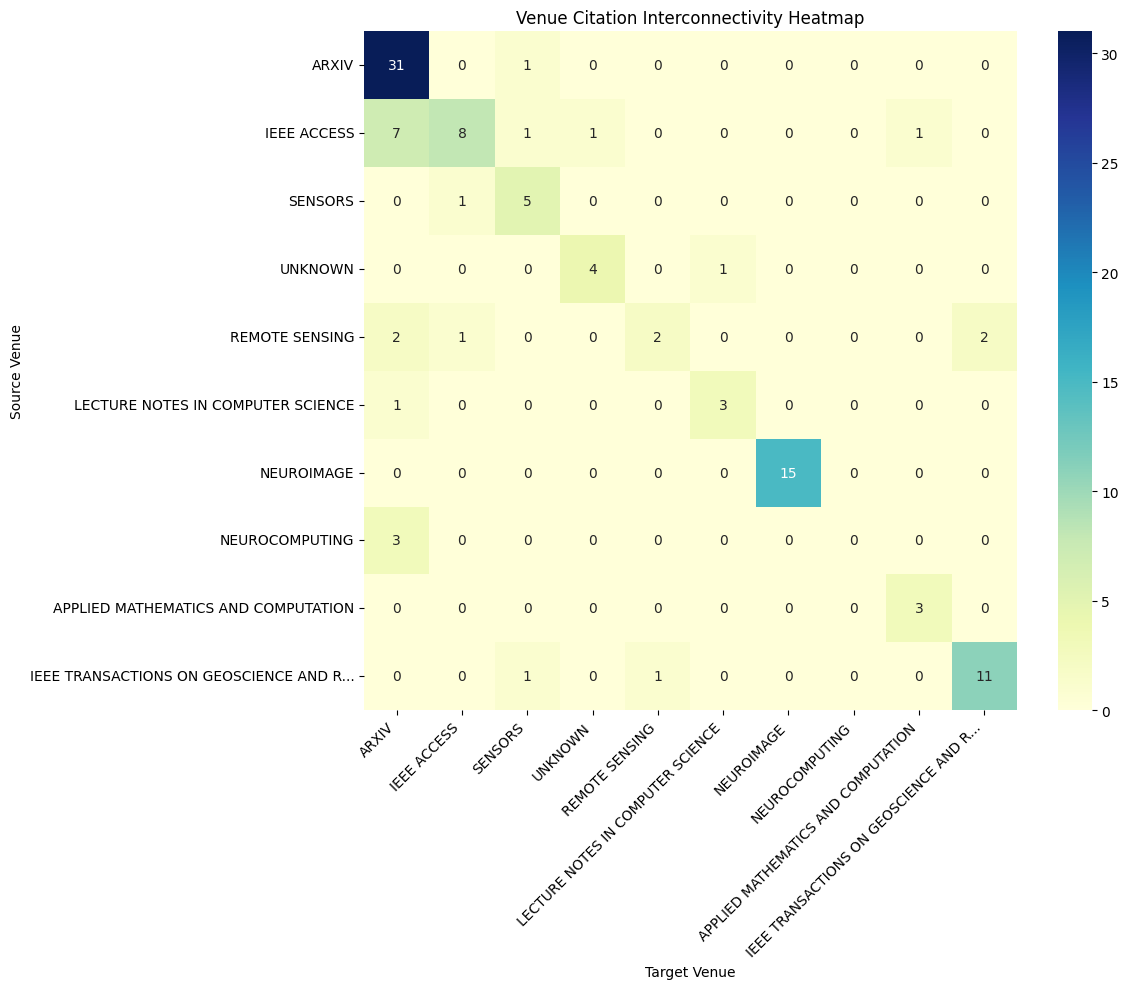

In [21]:
# Constructs undirected co-authorship graph
# @param dataFrame - Dataset containing authors list
# @returns - Undirected graph object
def buildCoauthorGraph(dataFrame):
    undirectedGraph = nx.Graph()
    for authors in dataFrame["authors"]:
        authorCount = len(authors)
        for i in range(authorCount):
            undirectedGraph.add_node(authors[i])
            for j in range(i + 1, authorCount):
                undirectedGraph.add_edge(authors[i], authors[j])
    return undirectedGraph

coauthorGraph = buildCoauthorGraph(analyticalData)
averageClustering = nx.average_clustering(coauthorGraph)
print(f"Co-authorship network average clustering coefficient: {averageClustering}")

# Constructs venue interconnectivity matrix
# @param dataFrame - Dataset containing id, venue, and references
# @param topK - Number of top venues to analyze
# @returns - DataFrame representing adjacency matrix
def buildVenueInterconnectivity(dataFrame, topK):
    topVenues = dataFrame["venue"].value_counts().head(topK).index.tolist()
    idToVenue = dict(zip(dataFrame["id"], dataFrame["venue"]))
    interconnectivity = pd.DataFrame(0, index=topVenues, columns=topVenues)
    for _, row in dataFrame.iterrows():
        sourceVenue = row["venue"]
        if sourceVenue in topVenues:
            for referenceId in row["references"]:
                targetVenue = idToVenue.get(referenceId)
                if targetVenue in topVenues:
                    interconnectivity.loc[sourceVenue, targetVenue] += 1
    return interconnectivity

venueHeatmapData = buildVenueInterconnectivity(analyticalData, 10)
plt.figure(figsize=(12, 10))
sns.heatmap(venueHeatmapData, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Venue Citation Interconnectivity Heatmap")
plt.xlabel("Target Venue")
plt.ylabel("Source Venue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
